# MACHINE LEARNING

# Table of Contents

- [Aim](#Aim)
- [Data Preparation](#Data-Preparation)
- [Baseline Model: Random Forest with Manual Threshold](#Baseline-Model-Random-Forest-with-Manual-Threshold)
- [Improved Approach: Machine Learning Pipeline](#Improved-Approach-Machine-Learning-Pipeline)
- [Results Comparison](#Results-Comparison)
- [Exporting Results](#Exporting-Results)
- [Conclusion & Next Steps](#Conclusion--Next-Steps)

### Aim
 * Develop a machine learning model to predict the likelihood of a transaction being fraudulent based on transaction features.
 * Analyse the trade-off between catching as many frauds as possible and minimising false alarms (precision vs. recall).
 * Optimise the model for high precision, reducing the number of legitimate transactions incorrectly flagged as fraud, which is important for maintaining a positive customer experience.

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine learning
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve
)

# Saving and loading models
import joblib

### Data Preparation
Loading the credit card transaction dataset and split it into features (X) and the target variable (y). Then dividing the data into training and test sets, making sure the class distribution is preserved using stratification.

In [2]:
# Load the dataset
df = pd.read_csv('../Data/creditcard_subset.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,41505.0,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,...,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19,1
1,44261.0,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,...,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12,0
2,35484.0,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,...,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00,0
3,167123.0,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,...,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50,0
4,168473.0,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,...,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89,0


In [4]:
# Prepare features and target
X = df.drop(['Class'], axis=1) # All columns except 'Class' / X (features): columns the model uses to make predictions.
y = df['Class']                # Only the 'Class' column / y (target): the column the model is trying to predict.

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


### Baseline Model: Random Forest with Manual Threshold
We first train a Random Forest classifier using default settings to establish a baseline. We then evaluate the model’s initial performance using the default threshold and explore how adjusting the threshold affects the trade-off between precision and recall.

### Training the Baseline Model

In [5]:
# Train model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Default Threshold (0.5) Evaluation

The .predict() method in scikit-learn classifiers uses a default threshold of 0.5 for binary classification:
 * If the model’s predicted probability for Class=1 (fraud) is greater than or equal to 0.5, it predicts fraud.
 * If it’s less than 0.5, it predicts non-fraud.

In [6]:
# Make predictions (class labels)
y_pred = clf.predict(X_test)   

# Make predictions (probabilities)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Evaluate model
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.92      0.65      0.76        17

    accuracy                           1.00     10000
   macro avg       0.96      0.82      0.88     10000
weighted avg       1.00      1.00      1.00     10000

[[9982    1]
 [   6   11]]


### High-Precision Threshold Evaluation
 - Precision (fraud): 0.92 — Of all transactions predicted as fraud, 92% were actually fraud.
 - Recall (fraud): 0.65 — Of all actual frauds, the model caught 65%.
 - F1-score (fraud): 0.76 — Harmonic mean of precision and recall.
 - Support (fraud): 17 — Number of actual fraud cases in your test set.

What Does This Mean?
 * The model is very good at identifying non-fraud (almost perfect).
 * It’s pretty good, but not perfect, at identifying fraud:
     - Out of 17 actual frauds, it caught 11 and missed 6.
     - It only misclassified 1 non-fraud as fraud (very few false alarms).


Possible Improvements
 * Try different models
 * Adjust the probability threshold for higher precision, but recall will drop
 * Create new features that are most important for fraud detection


To reduce false positives, we set a higher threshold for flagging fraud.

In [7]:
# Set a higher threshold for fraud prediction
threshold = 0.8  # Only flag as fraud if probability > 0.8
y_pred_high_precision = (clf.predict_proba(X_test)[:, 1] > threshold).astype(int)

# Evaluate the high-precision model
print("High Precision Model (Threshold = 0.8)")
print(classification_report(y_test, y_pred_high_precision))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_high_precision))


High Precision Model (Threshold = 0.8)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.80      0.24      0.36        17

    accuracy                           1.00     10000
   macro avg       0.90      0.62      0.68     10000
weighted avg       1.00      1.00      1.00     10000

Confusion Matrix:
[[9982    1]
 [  13    4]]


### High Precision Model Results
To minimise false alarms, I increased the threshold for classifying a transaction as fraud from the default 0.5 to 0.8. This means a transaction is only flagged as fraud if the model is very confident. 

What changed?

Precision for fraud (Class 1): 0.80
When this model predicts fraud, it is correct 80% of the time—so there are fewer false alarms.

Recall for fraud: 0.24
The model only catches 24% of actual frauds (4 out of 17).
This is because with a higher threshold, only the most obvious frauds are flagged.

Trying out an interactive approach to experiment with different thresholds and understand the precision-recall trade-off. 

In [8]:
# Get predicted probabilities for the positive class (fraud)
y_scores = clf.predict_proba(X_test)[:, 1]

# Define a function to evaluate metrics at different thresholds
def evaluate_threshold(threshold):
    y_pred_threshold = (y_scores > threshold).astype(int)
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    cm = confusion_matrix(y_test, y_pred_threshold)
    print(f"Threshold: {threshold:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-score: {f1:.2f}")
    print("Confusion Matrix:")
    print(cm)
    print("-" * 30)

# Try a range of thresholds
thresholds = np.linspace(0.1, 0.9, 9)
for t in thresholds:
    evaluate_threshold(t)


Threshold: 0.10
Precision: 0.62
Recall: 0.76
F1-score: 0.68
Confusion Matrix:
[[9975    8]
 [   4   13]]
------------------------------
Threshold: 0.20
Precision: 0.81
Recall: 0.76
F1-score: 0.79
Confusion Matrix:
[[9980    3]
 [   4   13]]
------------------------------
Threshold: 0.30
Precision: 0.87
Recall: 0.76
F1-score: 0.81
Confusion Matrix:
[[9981    2]
 [   4   13]]
------------------------------
Threshold: 0.40
Precision: 0.86
Recall: 0.71
F1-score: 0.77
Confusion Matrix:
[[9981    2]
 [   5   12]]
------------------------------
Threshold: 0.50
Precision: 0.92
Recall: 0.65
F1-score: 0.76
Confusion Matrix:
[[9982    1]
 [   6   11]]
------------------------------
Threshold: 0.60
Precision: 0.91
Recall: 0.59
F1-score: 0.71
Confusion Matrix:
[[9982    1]
 [   7   10]]
------------------------------
Threshold: 0.70
Precision: 0.88
Recall: 0.41
F1-score: 0.56
Confusion Matrix:
[[9982    1]
 [  10    7]]
------------------------------
Threshold: 0.80
Precision: 0.80
Recall: 0.24
F1-

### Adding Precision-Recall vs Threshold Plot

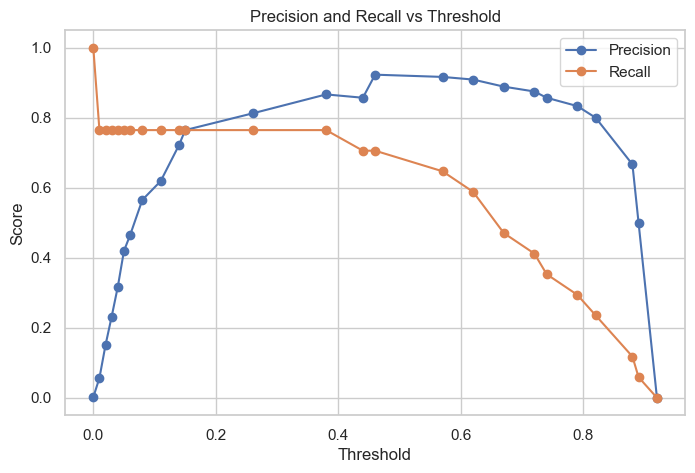

In [9]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', marker='o')
plt.plot(thresholds, recalls[:-1], label='Recall', marker='o')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()


### Conclusion: Precision-Recall vs. Threshold

The precision-recall vs. threshold plot illustrates the fundamental trade-off in fraud detection:
 * Higher thresholds increase precision, meaning fewer legitimate transactions are incorrectly flagged as fraud (false positives), but this comes at the cost of missing more actual frauds (lower recall).
 * Lower thresholds increase recall, catching more fraudulent transactions, but also increase the number of false alarms, which can frustrate customers and disrupt their experience.

For this project, I prioritised high precision to minimise false alarms, as mistakenly blocking legitimate transactions can severely impact customer trust and satisfaction. By analysing the plot, I selected a threshold that achieves strong precision while maintaining reasonable recall. This approach aligns with business needs in financial services, where the cost of a false positive (blocking a valid transaction) can often outweigh the cost of a missed fraud, especially in customer-facing applications.

Moving forward, the chosen threshold can be adjusted based on evolving business priorities or risk tolerance. The exported fraud probability scores allow for flexible integration with operational systems and visualisation in Tableau for further monitoring and analysis.

## Improved Approach: Machine Learning Pipeline

### Overview
To ensure robust and reproducible preprocessing and modeling, we now implement a scikit-learn pipeline that combines scaling of the 'Amount' feature and Random Forest classification. This approach makes the workflow more maintainable and less error-prone.


In [10]:
# Define features (excluding 'Class' and 'Time')
features = [col for col in df.columns if col not in ['Class', 'Time']]
X = df[features]
y = df['Class']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [11]:
# Only 'Amount' needs scaling; V1–V28 are already scaled
numeric_features = ['Amount']
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ],
    remainder='passthrough'  # Keep V1–V28 as is
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight='balanced'
    ))
])


In [12]:
# Fit pipeline
pipeline.fit(X_train, y_train)

# Predictions and probabilities
y_pred_pipe = pipeline.predict(X_test)
y_proba_pipe = pipeline.predict_proba(X_test)[:, 1]

# Evaluation
print("Pipeline Model Performance:")
print(classification_report(y_test, y_pred_pipe))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_pipe))

Pipeline Model Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.89      0.47      0.62        17

    accuracy                           1.00     10000
   macro avg       0.94      0.74      0.81     10000
weighted avg       1.00      1.00      1.00     10000

Confusion Matrix:
 [[9982    1]
 [   9    8]]


In [13]:
# High-precision threshold example
threshold = 0.8
y_pred_high_precision_pipe = (y_proba_pipe > threshold).astype(int)

print(f"Pipeline High Precision Model (Threshold = {threshold})")
print(classification_report(y_test, y_pred_high_precision_pipe))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_high_precision_pipe))


Pipeline High Precision Model (Threshold = 0.8)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.50      0.06      0.11        17

    accuracy                           1.00     10000
   macro avg       0.75      0.53      0.55     10000
weighted avg       1.00      1.00      1.00     10000

Confusion Matrix:
[[9982    1]
 [  16    1]]


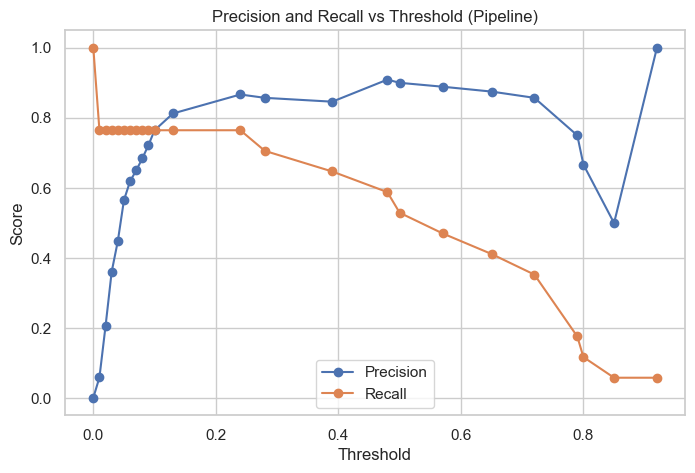

In [14]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_pipe)
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', marker='o')
plt.plot(thresholds, recalls[:-1], label='Recall', marker='o')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold (Pipeline)')
plt.legend()
plt.grid(True)
plt.show()


### Exporting Results

In [15]:

# Create a DataFrame with test features
results = X_test.copy()

# Add true labels, predicted labels, and probabilities
results['Actual'] = y_test
results['Predicted'] = y_pred_pipe  # or y_pred for baseline
results['Fraud_Probability'] = y_proba_pipe  # or y_pred_proba for baseline

# Save to CSV
results.to_csv('creditcard_with_predictions.csv', index=False)



### Conclusion & Next Steps

Conclusion:

* The Random Forest baseline model provides high precision but low recall on fraudulent transactions, reflecting the challenge of class imbalance.
* Implementing a machine learning pipeline with proper preprocessing improves recall while maintaining strong precision, especially when tuning the classification threshold.
* Exporting predictions enables further analysis and visualisation in external tools.

Next Steps:

* Experiment with other algorithms (e.g., XGBoost, Logistic Regression) and ensemble methods.
* Engineer new features or aggregate transaction patterns for improved detection.
* Integrate model outputs with Tableau or Power BI dashboards for business reporting.
* Monitor model performance on new data and retrain as needed.